In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import gzip
import shutil
import numpy as np
with gzip.open('data_3.4/RT.fits.gz', 'rb') as f_in:
    with open('data_3.4/RT.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
with gzip.open('data_th/Temperature.fits.gz', 'rb') as f_in:
    with open('data_th/Temperature.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

Filename: data_3.4/RT.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      24   (30, 30, 1, 1, 1)   float32   
  1                1 ImageHDU        10   (1, 1, 1, 2)   float32   
  2                1 ImageHDU         9   (1, 1, 1)   float32   
  3                1 ImageHDU         8   (3, 1)   float32   
1.4784409e-12


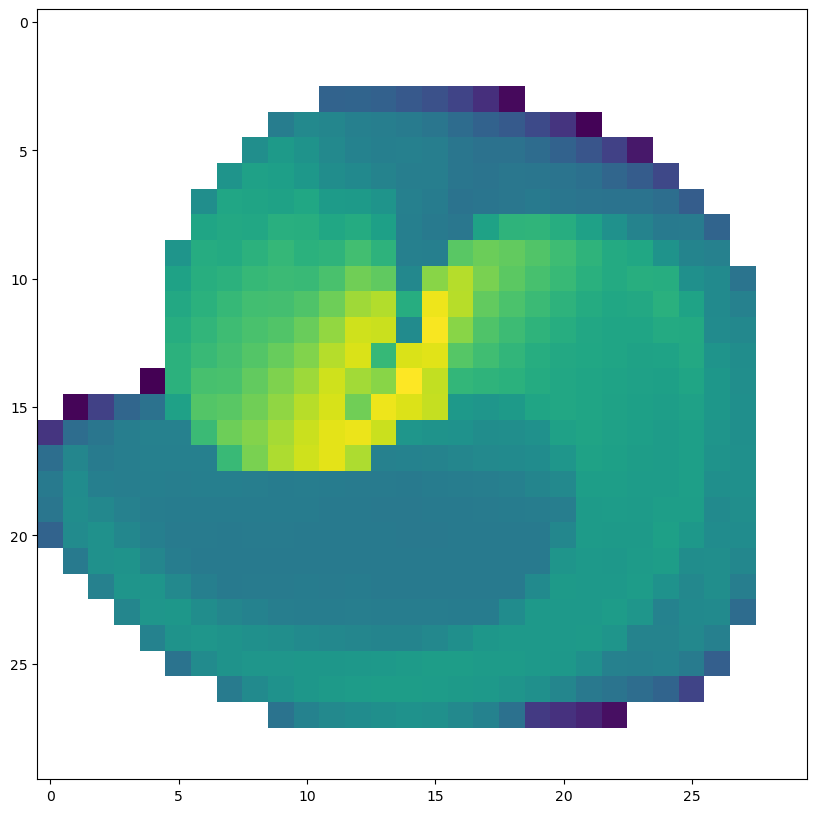

In [2]:
hdul = fits.open("data_3.4/RT.fits")
hdul.info()

data = hdul[0].data[0][0][0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(data[::-1, :], cmap='viridis', norm='log')

fig.savefig('image.png', dpi=400)

print(np.sum(data))

Filename: data_th/Temperature.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (102397,)   float32   


(array([8.000e+00, 1.800e+01, 5.600e+01, 1.590e+02, 4.240e+02, 9.500e+02,
        1.982e+03, 3.057e+03, 3.948e+03, 4.360e+03, 4.095e+03, 3.674e+03,
        3.325e+03, 3.148e+03, 2.865e+03, 3.033e+03, 2.912e+03, 2.546e+03,
        2.491e+03, 2.712e+03, 2.651e+03, 2.310e+03, 1.756e+03, 1.650e+03,
        1.698e+03, 1.850e+03, 2.046e+03, 1.977e+03, 1.994e+03, 2.053e+03,
        2.066e+03, 1.853e+03, 1.696e+03, 1.519e+03, 1.313e+03, 1.311e+03,
        1.178e+03, 1.249e+03, 1.139e+03, 1.147e+03, 1.152e+03, 1.129e+03,
        1.088e+03, 1.034e+03, 1.011e+03, 1.011e+03, 9.920e+02, 9.660e+02,
        8.910e+02, 9.010e+02, 8.590e+02, 8.020e+02, 7.850e+02, 7.770e+02,
        7.310e+02, 7.340e+02, 7.190e+02, 6.360e+02, 6.640e+02, 6.580e+02,
        6.210e+02, 6.130e+02, 6.160e+02, 6.160e+02, 6.070e+02, 5.620e+02,
        4.660e+02, 3.160e+02, 1.540e+02, 5.500e+01, 1.000e+01, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

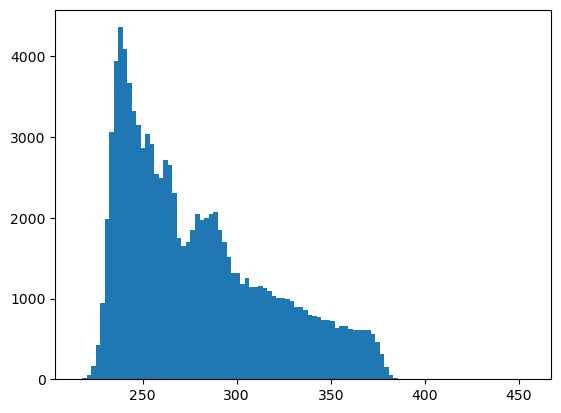

In [3]:

temps = fits.open("data_th/Temperature.fits")
temps.info()

temp_data = temps[0].data

fig, ax = plt.subplots()
ax.hist(temp_data, bins=100)

In [4]:
raw_densities = fits.open("apep1shell.fits")
raw_densities.info()

masses = raw_densities[0].data
weights = masses / max(masses)

particles = raw_densities[1].data
print(particles.shape)

Filename: apep1shell.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   (102398,)   float64   
  1                1 ImageHDU         7   (3, 102398)   float64   
(102398, 3)


/tmp/ipykernel_299939/798996632.py:11: RuntimeWarning: invalid value encountered in divide
  H /= H_norm


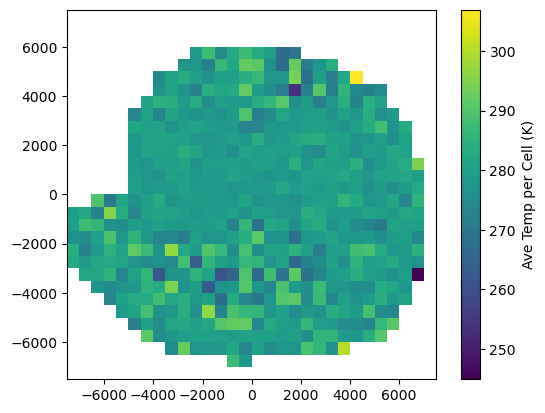

In [5]:
import numpy as np

resolution = hdul[0].data[0][0][0].shape[0]
indices = range(len(temp_data))
bound = np.max(np.abs(particles[indices, :2]))
pixels = np.linspace(-bound, bound, resolution + 1)

H, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels, weights=temp_data)
H_norm, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels)

H /= H_norm

fig, ax = plt.subplots()

# ax.scatter(particles[indices, 0], particles[indices, 1], c=temp_data, s=0.1)
# ax.set(aspect='equal')
p = ax.pcolormesh(x, y, H.T)
ax.set(aspect='equal')
fig.colorbar(p, label='Ave Temp per Cell (K)')

In [6]:
wcs

NameError: name 'wcs' is not defined